In [44]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random

In [45]:
load_dotenv(override=True)

True

In [46]:
# Some useful constants

nouns = ["Cabbages", "Unicorns", "Toasters", "Penguins", "Bananas", "Zombies", "Rainbows", "Eels", "Pickles", "Muffins"]
adjectives = ["outrageous", "smelly", "pedantic", "existential", "moody", "sparkly", "untrustworthy", "sarcastic", "squishy", "haunted"]

In [47]:
class State(BaseModel):
    messages: Annotated[list, add_messages]

In [48]:
graph_builder = StateGraph(State)

In [49]:
def my_first_node(old_state : State) -> State:
    reply = f"{random.choice(nouns)} are {random.choice(adjectives)}"
    messages = [{"role":"assistant", "content" : reply}]
    new_state = State(messages=messages)
    return new_state

graph_builder.add_node("first_node",my_first_node)

In [50]:
graph_builder.add_edge(START, "first_node")
graph_builder.add_edge("first_node", END)

In [51]:
graph = graph_builder.compile()

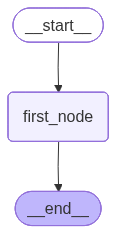

In [52]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [53]:
def chat(user_input: str, history):
    message = {"role":"user", "content": user_input}
    messages = [message]
    state = State(messages=messages)
    result = graph.invoke(state)
    print(result)
    return result["messages"][-1].content

In [ ]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


/Users/nikhilsharma/Downloads/Internal Drive/Personal Projects/AI-Projects/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/Users/nikhilsharma/Downloads/Internal Drive/Personal Projects/AI-Projects/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='01ee2ac6-a125-4182-894e-cfebefedfd1c'), AIMessage(content='Penguins are sarcastic', additional_kwargs={}, response_metadata={}, id='7b5344cb-4f11-4d85-8ea1-a7e519d0f9f7', tool_calls=[], invalid_tool_calls=[])]}


/Users/nikhilsharma/Downloads/Internal Drive/Personal Projects/AI-Projects/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/Users/nikhilsharma/Downloads/Internal Drive/Personal Projects/AI-Projects/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


{'messages': [HumanMessage(content='okay', additional_kwargs={}, response_metadata={}, id='2bc9a2c3-05b4-4c78-9f3f-d91948b82dd5'), AIMessage(content='Bananas are sarcastic', additional_kwargs={}, response_metadata={}, id='8ebd2053-d28d-4df5-a788-680f3c6d1f51', tool_calls=[], invalid_tool_calls=[])]}


/Users/nikhilsharma/Downloads/Internal Drive/Personal Projects/AI-Projects/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/Users/nikhilsharma/Downloads/Internal Drive/Personal Projects/AI-Projects/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


{'messages': [HumanMessage(content=':)', additional_kwargs={}, response_metadata={}, id='3f37e42d-2b42-4cdf-bc69-7016ee978f74'), AIMessage(content='Unicorns are sarcastic', additional_kwargs={}, response_metadata={}, id='8fedf75d-6ff0-4ac2-8b84-715d9f909954', tool_calls=[], invalid_tool_calls=[])]}
